# Задание 7. Многорукие бандиты в рекомендательных системах

Необходимо исследовать применение многоруких бандитов в рекомендательных системах.

В качестве «рук» используются пять уже разработанных рекомендателей:
- SVD;
- UserKNN;
- ItemKNN;
- Content-Based;
- Hybrid.

Бандит на каждом шаге выбирает одну из этих моделей, после чего получает награду в зависимости от качества сформированных рекомендаций.

Исследуются три основных алгоритма многоруких бандитов:
- Epsilon-Greedy;
- UCB;
- Thompson Sampling.

Основная задача состоит в том, чтобы сравнить скорость обучения алгоритмов, накопленную награду и распределение выбора рук.

Важно учитывать, что эксперимент является offline-симуляцией: пользовательские тестовые оценки используются как имитация обратной связи, а не как реальные online-взаимодействия.

## Структура и анализ данных

Используется тот же Goodbooks-10k Extended.

Основные данные:
- `ratings.csv` — пользовательские оценки;
- `books_enriched.csv` — информация о книгах.

Используется разбиение 80/20 с `random_state = 42`.

Книги с тестовой оценкой не ниже 4 считаются релевантными.

Для оценки всех рекомендателей используется одинаковая выборка пользователей, чтобы сравнение между руками было корректным.

В эксперименте используется 200 пользователей, имеющих хотя бы одну релевантную книгу в тестовой выборке.

In [35]:
import time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import linear_kernel
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
warnings.filterwarnings('ignore')

DATA_DIR = 'goodbooks-10k-extended'
PARAMS = {
    'TEST_SIZE':0.20,'RANDOM_STATE':42,'RELEVANCE_THRESHOLD':4,
    'N_EVAL_USERS':400,'TOP_N':10,
    'SVD_COMPONENTS':10,
    'USER_K':50,'ITEM_K':50,
    'CB_MIN_LIKE':3,'CB_PROFILE_ITEMS':50,
    'CB_NGRAM_RANGE':(1,5),'CB_MAX_FEATURES':30000,
    'HYBRID_CB_CANDIDATES':800,
    'HORIZON':5000,'N_RUNS':20,
    'EPSILON':0.10,'UCB_C':1.0
}
np.random.seed(PARAMS['RANDOM_STATE'])

## Загрузка данных

Загружаются оценки и метаданные книг.

Кроме основной статистики формируется матрица взаимодействий пользователей и книг, которая затем используется моделями SVD, UserKNN и ItemKNN.

In [36]:
def load_data():
    ratings = pd.read_csv(f'{DATA_DIR}/ratings.csv',usecols=['user_id','book_id','rating'])
    books = pd.read_csv(f'{DATA_DIR}/books_enriched.csv')
    if 'book_id' not in books.columns: books = books.rename(columns={books.columns[0]:'book_id'})
    ratings = ratings.dropna(subset=['user_id','book_id','rating']).copy()
    books = books.dropna(subset=['book_id']).copy()
    ratings[['user_id','book_id']] = ratings[['user_id','book_id']].astype(np.int32)
    ratings['rating'] = ratings['rating'].astype(np.float32)
    books['book_id'] = books['book_id'].astype(np.int32)
    for col in ['title','authors','genres','description']:
        if col not in books.columns: books[col] = ''
        books[col] = books[col].fillna('').astype(str)
    return ratings,books

ratings_df,books_df = load_data()

train_df,test_df = train_test_split(
    ratings_df,test_size=PARAMS['TEST_SIZE'],random_state=PARAMS['RANDOM_STATE']
)

book_ids = pd.Index(np.sort(train_df['book_id'].unique()))
book_to_idx = pd.Series(np.arange(len(book_ids)),index=book_ids)

user_ids = pd.Index(np.sort(train_df['user_id'].unique()))
user_to_idx = pd.Series(np.arange(len(user_ids)),index=user_ids)

rows = train_df['user_id'].map(user_to_idx).to_numpy()
cols = train_df['book_id'].map(book_to_idx).to_numpy()
data = train_df['rating'].to_numpy(dtype=np.float32)
R = csr_matrix((data,(rows,cols)),shape=(len(user_ids),len(book_ids)))

test_relevant = {
    uid:set(g.loc[g['rating']>=PARAMS['RELEVANCE_THRESHOLD'],'book_id'])
    for uid,g in test_df.groupby('user_id')
}

candidate_users = np.array([
    uid for uid in train_df['user_id'].unique()
    if uid in test_relevant and len(test_relevant[uid])>0
])

np.random.seed(PARAMS['RANDOM_STATE'])
sample_eval_users = np.random.choice(
    candidate_users,size=min(PARAMS['N_EVAL_USERS'],len(candidate_users)),replace=False
)

user_row_cache = {int(uid):int(user_to_idx[uid]) for uid in sample_eval_users}
seen_cache = {
    int(uid):set(train_df.loc[train_df['user_id']==uid,'book_id'])
    for uid in sample_eval_users
}

print(f'Пользователей: {len(user_ids):,}')
print(f'Книг:           {len(book_ids):,}')
print(f'Оценок train:   {len(train_df):,}')
print(f'Оценок test:    {len(test_df):,}')
print(f'Пользователей для bandit: {len(sample_eval_users)}')

Пользователей: 53,424
Книг:           10,000
Оценок train:   4,781,183
Оценок test:    1,195,296
Пользователей для bandit: 400


## Руки многорукого бандита

Каждая рука представляет отдельную рекомендательную модель.

**SVD** использует скрытые факторы взаимодействий.

**UserKNN** ищет похожих пользователей и использует их оценки.

**ItemKNN** рекомендует книги, похожие на книги, которые пользователь оценил положительно.

**Content-Based** использует название, авторов, жанры и описание книг. В качестве параметров используются лучшие значения из предыдущей работы: `MIN_RATING_LIKE = 3`, `MAX_PROFILE_ITEMS = 50`, `NGRAM_RANGE = (1,5)`.

**Hybrid** использует лучшую схему из задания 6: сначала Content-Based формирует набор из 800 кандидатов, затем User+Item KNN выполняет окончательное ранжирование.

Для SVD используются 10 компонент, а для UserKNN и ItemKNN — по 50 соседей.

## Подготовка SVD

SVD используется как одна из рук бандита.

Для каждого пользователя рассчитывается латентный профиль, после чего книги ранжируются по восстановленной оценке.

In [37]:
svd = TruncatedSVD(
    n_components=PARAMS['SVD_COMPONENTS'],
    n_iter=7,
    random_state=PARAMS['RANDOM_STATE']
)

svd_start = time.time()
USER_FACTORS = svd.fit_transform(R)

print(f'SVD построен за {time.time()-svd_start:.1f} сек.')
print(f'Компонент: {PARAMS["SVD_COMPONENTS"]}')
print(f'Объяснённая дисперсия: {svd.explained_variance_ratio_.sum():.4f}')

SVD построен за 0.4 сек.
Компонент: 10
Объяснённая дисперсия: 0.0899


## Подготовка UserKNN и ItemKNN

Для UserKNN и ItemKNN используются 50 соседей.

Чтобы ускорить эксперимент, соседей не пересчитываем во время работы бандитов. Все необходимые оценки предварительно кэшируются.

In [38]:
user_knn = NearestNeighbors(
    n_neighbors=PARAMS['USER_K']+1,
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
).fit(R)

item_knn = NearestNeighbors(
    n_neighbors=PARAMS['ITEM_K']+1,
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
).fit(R.T)

USER_NEIGHBOR_CACHE = {}
ITEM_NEIGHBOR_CACHE = {}

print('Кэширование UserKNN...')
start = time.time()

eval_rows = np.array([user_row_cache[int(uid)] for uid in sample_eval_users])
distances,neighbors = user_knn.kneighbors(
    R[eval_rows],
    n_neighbors=PARAMS['USER_K']+1
)

for i,uid in enumerate(sample_eval_users):
    USER_NEIGHBOR_CACHE[int(uid)] = (
        neighbors[i][1:],
        np.maximum(1-distances[i][1:],0)
    )

print(f'UserKNN: {time.time()-start:.1f} сек.')

liked_ids = set()

for uid in sample_eval_users:
    liked = train_df[
        (train_df['user_id']==uid)&
        (train_df['rating']>=4)
    ].sort_values('rating',ascending=False).head(50)
    liked_ids.update(int(x) for x in liked['book_id'] if x in book_to_idx.index)

liked_ids = list(liked_ids)

print(f'Книг для ItemKNN: {len(liked_ids):,}')
start = time.time()

for pos in range(0,len(liked_ids),100):
    chunk = liked_ids[pos:pos+100]
    query_idx = [int(book_to_idx[x]) for x in chunk]
    distances,neighbors = item_knn.kneighbors(
        R.T[query_idx],
        n_neighbors=PARAMS['ITEM_K']+1
    )

    for j,bid in enumerate(chunk):
        ITEM_NEIGHBOR_CACHE[bid] = (
            neighbors[j][1:],
            np.maximum(1-distances[j][1:],0)
        )

    done = min(pos+100,len(liked_ids))
    print(
        f'ItemKNN: {done}/{len(liked_ids)} '
        f'({100*done/len(liked_ids):.1f}%)',
        end='\r'
    )

print(f'\nItemKNN: {time.time()-start:.1f} сек.')

Кэширование UserKNN...
UserKNN: 0.3 сек.
Книг для ItemKNN: 5,872
ItemKNN: 5872/5872 (100.0%)
ItemKNN: 6.0 сек.


## Подготовка Content-Based

Для Content-Based формируется текст из названия, авторов, жанров и описания.

Используется TF-IDF с параметрами из предыдущего задания: `MIN_RATING_LIKE = 3`, `MAX_PROFILE_ITEMS = 50`, `NGRAM_RANGE = (1,5)`.

In [39]:
book_data = books_df.set_index('book_id').reindex(book_ids).fillna('')

book_texts = (
    book_data['title']+' '+
    book_data['authors']+' '+
    book_data['genres'].str.replace('|',' ',regex=False)+' '+
    book_data['description']
)

vectorizer = TfidfVectorizer(
    max_features=PARAMS['CB_MAX_FEATURES'],
    ngram_range=PARAMS['CB_NGRAM_RANGE'],
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents='unicode'
)

tfidf_start = time.time()
TFIDF = vectorizer.fit_transform(book_texts)

print(f'TF-IDF построен за {time.time()-tfidf_start:.1f} сек.')
print(f'Размер матрицы: {TFIDF.shape}')

TF-IDF построен за 19.4 сек.
Размер матрицы: (10000, 30000)


## Реализация функций рекомендаций

Для каждого пользователя заранее рассчитываются Top-10 рекомендаций всех пяти рук.

Это существенно ускоряет bandit-эксперимент, поскольку во время обучения бандита уже не выполняются тяжёлые операции SVD, KNN или TF-IDF.

In [40]:
def top_ids(scores,n=10,seen=None):
    scores = np.asarray(scores).copy()
    if seen:
        idx = [book_to_idx[x] for x in seen if x in book_to_idx.index]
        scores[idx] = -np.inf
    order = np.argpartition(-scores,min(n,len(scores))-1)[:n]
    order = order[np.argsort(-scores[order])]
    return [int(book_ids[i]) for i in order]

def rec_svd(uid,n=10):
    uidx = user_row_cache[int(uid)]
    scores = USER_FACTORS[uidx] @ svd.components_
    return top_ids(scores,n,seen_cache[int(uid)])

def user_scores(uid):
    neighbors,sims = USER_NEIGHBOR_CACHE[int(uid)]
    scores = np.asarray(
        R[neighbors].multiply(sims[:,None]).sum(axis=0)
    ).ravel()
    return scores

def rec_user_knn(uid,n=10):
    return top_ids(user_scores(uid),n,seen_cache[int(uid)])

def item_scores(uid):
    result = np.zeros(len(book_ids),dtype=np.float32)
    liked = train_df[
        (train_df['user_id']==uid)&
        (train_df['rating']>=4)
    ].sort_values('rating',ascending=False).head(50)

    for bid,rating in zip(liked['book_id'],liked['rating']):
        bid = int(bid)
        if bid not in ITEM_NEIGHBOR_CACHE: continue

        neighbors,sims = ITEM_NEIGHBOR_CACHE[bid]
        result[neighbors] += sims * float(rating)

    return result

def rec_item_knn(uid,n=10):
    return top_ids(item_scores(uid),n,seen_cache[int(uid)])

def cb_profile(uid):
    liked = train_df[
        (train_df['user_id']==uid)&
        (train_df['rating']>=PARAMS['CB_MIN_LIKE'])
    ].sort_values('rating',ascending=False).head(PARAMS['CB_PROFILE_ITEMS'])

    if liked.empty: return None

    idxs = liked['book_id'].map(book_to_idx).to_numpy()
    weights = liked['rating'].to_numpy(dtype=np.float32)

    return normalize(
        csr_matrix(
            TFIDF[idxs].multiply(weights[:,None]).sum(axis=0)
        )
    )

def cb_scores(uid):
    profile = cb_profile(uid)
    if profile is None:
        return np.zeros(len(book_ids))

    return linear_kernel(profile,TFIDF).ravel()

def rec_content(uid,n=10):
    return top_ids(cb_scores(uid),n,seen_cache[int(uid)])

def rec_hybrid(uid,n=10):
    cb = cb_scores(uid)
    candidate_ids = top_ids(
        cb,
        PARAMS['HYBRID_CB_CANDIDATES'],
        seen_cache[int(uid)]
    )

    us = user_scores(uid)
    ins = item_scores(uid)

    candidate_idx = [book_to_idx[x] for x in candidate_ids]
    scores = 0.5*us[candidate_idx] + 0.5*ins[candidate_idx]

    order = np.argsort(-scores)[:n]
    return [candidate_ids[i] for i in order]

## Предварительный расчёт рекомендаций

Сначала рассчитываются рекомендации всех пяти моделей для всех пользователей оценки.

После этого формируется матрица наград.

Строка соответствует пользователю, столбец — одной руке.

In [41]:
ARMS = ['SVD','UserKNN','ItemKNN','Content','Hybrid']

recommendation_cache = {arm:{} for arm in ARMS}

start = time.time()

for i,uid in enumerate(sample_eval_users,1):
    uid = int(uid)

    recommendation_cache['SVD'][uid] = rec_svd(uid,PARAMS['TOP_N'])
    recommendation_cache['UserKNN'][uid] = rec_user_knn(uid,PARAMS['TOP_N'])
    recommendation_cache['ItemKNN'][uid] = rec_item_knn(uid,PARAMS['TOP_N'])
    recommendation_cache['Content'][uid] = rec_content(uid,PARAMS['TOP_N'])
    recommendation_cache['Hybrid'][uid] = rec_hybrid(uid,PARAMS['TOP_N'])

    if i == 1 or i % 10 == 0 or i == len(sample_eval_users):
        elapsed = time.time()-start
        speed = i/elapsed if elapsed else 0
        eta = (len(sample_eval_users)-i)/speed if speed else 0
        print(
            f'{i}/{len(sample_eval_users)} '
            f'({100*i/len(sample_eval_users):.1f}%), '
            f'осталось {eta:.1f} сек.',
            end='\r'
        )

print('\nРекомендации всех рук рассчитаны.')

400/400 (100.0%), осталось 0.0 сек.
Рекомендации всех рук рассчитаны.


## Матрица наград

Для каждого пользователя и каждой руки определяется бинарная награда.

`Reward = 1`, если в Top-10 присутствует хотя бы одна релевантная тестовая книга.

`Reward = 0` в противном случае.

Такой вариант награды соответствует Hit@10 и подходит для Epsilon-Greedy, UCB и Thompson Sampling.

In [42]:
reward_matrix = np.zeros((len(sample_eval_users),len(ARMS)),dtype=np.int8)

for i,uid in enumerate(sample_eval_users):
    relevant = test_relevant[int(uid)]

    for j,arm in enumerate(ARMS):
        recs = recommendation_cache[arm][int(uid)]
        reward_matrix[i,j] = int(any(x in relevant for x in recs))

arm_reward_stats = pd.DataFrame({
    'Arm':ARMS,
    'Mean Reward':reward_matrix.mean(axis=0),
    'Total Rewards':reward_matrix.sum(axis=0),
    'Users':len(sample_eval_users)
})

display(arm_reward_stats.round(6))

,Arm,Mean Reward,Total Rewards,Users
0,SVD,0.7750,310,400
1,UserKNN,0.8825,353,400
2,ItemKNN,0.8525,341,400
3,Content,0.5825,233,400
4,Hybrid,0.8450,338,400


## Алгоритмы многоруких бандитов

Исследуются три алгоритма.

**Epsilon-Greedy** в большинстве случаев выбирает руку с максимальной текущей средней наградой, но с вероятностью `epsilon` случайно исследует другую руку.

**UCB** учитывает не только среднюю награду, но и неопределённость оценки. Недостаточно испытанные руки получают дополнительный бонус.

**Thompson Sampling** поддерживает вероятностную оценку каждой руки и случайно выбирает руку на основе этой оценки. Для бинарной награды используется Beta-распределение.

Все алгоритмы начинают с одного обязательного выбора каждой руки, чтобы получить начальные наблюдения.

In [43]:
def run_epsilon_greedy(seed,horizon=5000,epsilon=0.1):
    rng = np.random.default_rng(seed)
    k = len(ARMS)
    counts = np.zeros(k,dtype=np.int64)
    rewards = np.zeros(k,dtype=np.int64)
    selected = np.zeros(horizon,dtype=np.int64)
    reward_history = np.zeros(horizon,dtype=np.int64)

    for t in range(horizon):
        if t < k:
            arm = t
        elif rng.random() < epsilon:
            arm = rng.integers(k)
        else:
            means = np.divide(rewards,counts,out=np.zeros(k,dtype=float),where=counts>0)
            arm = np.argmax(means)

        user_idx = rng.integers(len(sample_eval_users))
        reward = int(reward_matrix[user_idx,arm])

        counts[arm] += 1
        rewards[arm] += reward
        selected[t] = arm
        reward_history[t] = reward

    return {
        'selected':selected,
        'rewards_history':reward_history,
        'cumulative':np.cumsum(reward_history),
        'counts':counts,
        'rewards':rewards
    }


def run_ucb(seed,horizon=5000,c=1.0):
    rng = np.random.default_rng(seed)
    k = len(ARMS)
    counts = np.zeros(k,dtype=np.int64)
    rewards = np.zeros(k,dtype=np.int64)
    selected = np.zeros(horizon,dtype=np.int64)
    reward_history = np.zeros(horizon,dtype=np.int64)

    for t in range(horizon):
        if t < k:
            arm = t
        else:
            means = rewards / counts
            bonus = c * np.sqrt(np.log(t+1) / counts)
            arm = np.argmax(means + bonus)

        user_idx = rng.integers(len(sample_eval_users))
        reward = int(reward_matrix[user_idx,arm])

        counts[arm] += 1
        rewards[arm] += reward
        selected[t] = arm
        reward_history[t] = reward

    return {
        'selected':selected,
        'rewards_history':reward_history,
        'cumulative':np.cumsum(reward_history),
        'counts':counts,
        'rewards':rewards
    }


def run_thompson(seed,horizon=5000):
    rng = np.random.default_rng(seed)
    k = len(ARMS)
    successes = np.zeros(k,dtype=np.int64)
    failures = np.zeros(k,dtype=np.int64)
    selected = np.zeros(horizon,dtype=np.int64)
    reward_history = np.zeros(horizon,dtype=np.int64)

    for t in range(horizon):
        if t < k:
            arm = t
        else:
            samples = rng.beta(1+successes,1+failures)
            arm = np.argmax(samples)

        user_idx = rng.integers(len(sample_eval_users))
        reward = int(reward_matrix[user_idx,arm])

        if reward:
            successes[arm] += 1
        else:
            failures[arm] += 1

        selected[t] = arm
        reward_history[t] = reward

    return {
        'selected':selected,
        'rewards_history':reward_history,
        'cumulative':np.cumsum(reward_history),
        'counts':successes+failures,
        'rewards':successes.astype(float),
        'successes':successes,
        'failures':failures
    }

## Проведение экспериментов

Чтобы результат не зависел от одного случайного запуска, каждый алгоритм запускается несколько раз с различными random seed.

Основные параметры:
- горизонт — 5000 раундов;
- число запусков — 20;
- `epsilon = 0.10`;
- `UCB c = 1.0`.

Для каждого запуска сохраняются накопленная награда и количество выборов каждой руки.

In [44]:
HORIZON = PARAMS['HORIZON']
N_RUNS = PARAMS['N_RUNS']

all_runs = {
    'Epsilon-Greedy':[],
    'UCB':[],
    'Thompson Sampling':[]
}

start = time.time()

for run in range(N_RUNS):
    all_runs['Epsilon-Greedy'].append(
        run_epsilon_greedy(1000+run,HORIZON,PARAMS['EPSILON'])
    )
    all_runs['UCB'].append(
        run_ucb(2000+run,HORIZON,PARAMS['UCB_C'])
    )
    all_runs['Thompson Sampling'].append(
        run_thompson(3000+run,HORIZON)
    )

    print(
        f'Запуск {run+1}/{N_RUNS} '
        f'({100*(run+1)/N_RUNS:.1f}%)',
        end='\r'
    )

print(f'\nВсе запуски завершены за {time.time()-start:.1f} сек.')

Запуск 20/20 (100.0%)
Все запуски завершены за 3.2 сек.


## Накопленная награда

Первым показателем сравнения является накопленная награда.

Если алгоритм быстрее учится выбирать наиболее полезные руки, его кривая накопленной награды должна быстрее расти.

Для каждого алгоритма используется средняя кривая по всем запускам.

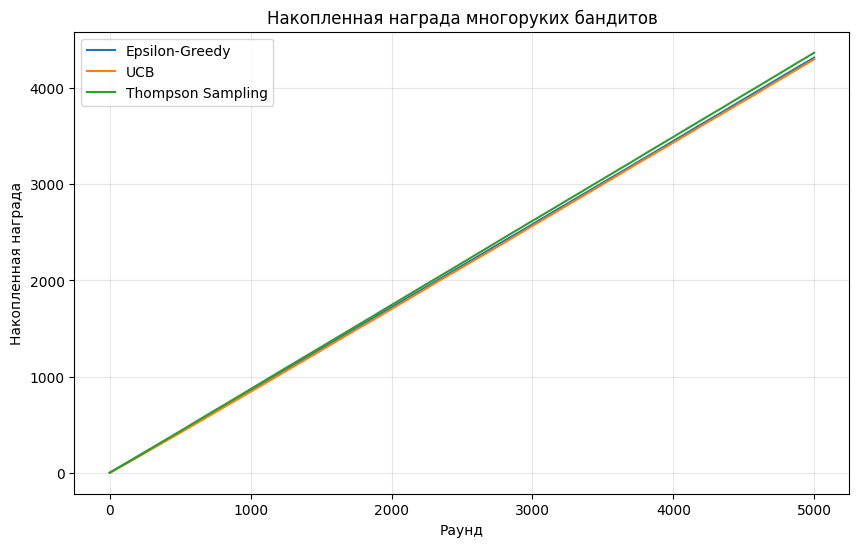

In [46]:
plt.figure(figsize=(10,6))

for name,runs in all_runs.items():
    curves = np.array([r['cumulative'] for r in runs])
    mean_curve = curves.mean(axis=0)
    plt.plot(mean_curve,label=name)

plt.xlabel('Раунд')
plt.ylabel('Накопленная награда')
plt.title('Накопленная награда многоруких бандитов')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Распределение выбора рук

Следующий показатель показывает, какую долю времени каждый алгоритм выбирает отдельные рекомендательные модели.

Если алгоритм хорошо определяет сильную руку, со временем доля её выборов должна увеличиваться, а менее эффективные руки — выбираться реже.

При этом Epsilon-Greedy продолжает случайно исследовать руки из-за параметра `epsilon`.

In [47]:
selection_rows = []

for name,runs in all_runs.items():
    counts = np.mean(
        np.array([r['counts'] for r in runs]),
        axis=0
    )

    for arm,count in zip(ARMS,counts):
        selection_rows.append({
            'Algorithm':name,
            'Arm':arm,
            'Mean Selections':count,
            'Share':count/HORIZON
        })

selection_df = pd.DataFrame(selection_rows)
display(selection_df.round(4))

,Algorithm,Arm,Mean Selections,Share
0,Epsilon-Greedy,SVD,110.75,0.0222
1,Epsilon-Greedy,UserKNN,3061.55,0.6123
2,Epsilon-Greedy,ItemKNN,975.55,0.1951
3,Epsilon-Greedy,Content,104.45,0.0209
4,Epsilon-Greedy,Hybrid,747.70,0.1495
5,UCB,SVD,303.20,0.0606
6,UCB,UserKNN,2661.00,0.5322
7,UCB,ItemKNN,1105.70,0.2211
8,UCB,Content,65.70,0.0131
9,UCB,Hybrid,864.40,0.1729


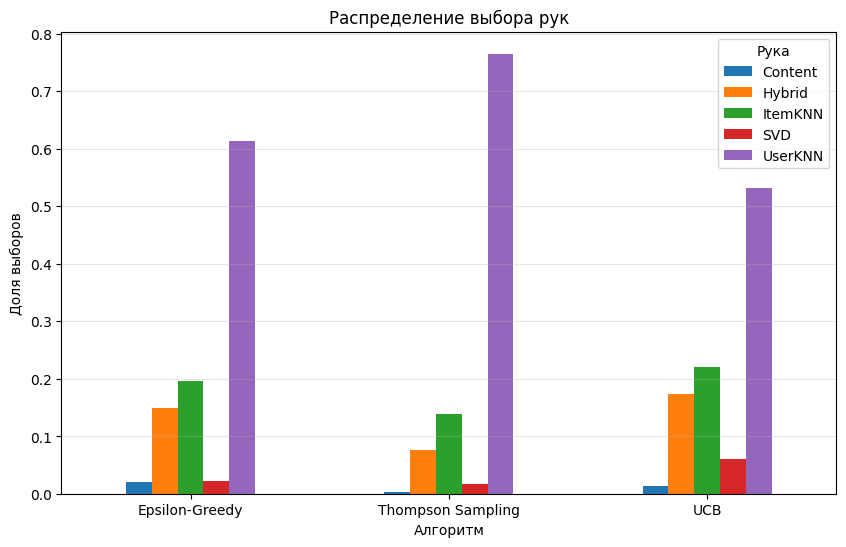

In [48]:
pivot = selection_df.pivot(
    index='Algorithm',
    columns='Arm',
    values='Share'
)

ax = pivot.plot(
    kind='bar',
    figsize=(10,6)
)

ax.set_xlabel('Алгоритм')
ax.set_ylabel('Доля выборов')
ax.set_title('Распределение выбора рук')
ax.legend(title='Рука')
plt.xticks(rotation=0)
plt.grid(axis='y',alpha=0.3)
plt.show()

## Итоговая статистика

Для каждого алгоритма рассчитываются:
- средняя итоговая накопленная награда;
- стандартное отклонение итоговой награды;
- средняя награда за один раунд;
- количество выборов каждой руки.

Дополнительно рассчитывается псевдорегрет относительно лучшей фиксированной руки на исследуемой выборке.

In [49]:
arm_means = reward_matrix.mean(axis=0)
best_static_reward = arm_means.max()

stats_rows = []

for name,runs in all_runs.items():
    final_rewards = np.array([r['cumulative'][-1] for r in runs])
    mean_reward = final_rewards.mean()

    mean_regret = np.mean([
        best_static_reward*HORIZON-r['cumulative'][-1]
        for r in runs
    ])

    stats_rows.append({
        'Algorithm':name,
        'Mean Final Reward':mean_reward,
        'Std Final Reward':final_rewards.std(),
        'Mean Reward / Round':mean_reward/HORIZON,
        'Mean Regret':mean_regret
    })

stats_df = pd.DataFrame(stats_rows)

display(stats_df.round(4))

,Algorithm,Mean Final Reward,Std Final Reward,Mean Reward / Round,Mean Regret
0,Epsilon-Greedy,4311.85,61.9324,0.8624,100.65
1,UCB,4294.95,28.1611,0.8590,117.55
2,Thompson Sampling,4362.85,36.3721,0.8726,49.65


## Статистика отдельных рук

Перед обучением бандитов полезно рассмотреть среднюю награду каждой руки.

Эта таблица показывает, насколько хорошо работают сами рекомендательные модели на одинаковой выборке пользователей.

Важно, что бандит не знает эту таблицу заранее. Он получает только награды от выбранной руки и постепенно оценивает её полезность.

In [50]:
arm_stats = pd.DataFrame({
    'Arm':ARMS,
    'Mean Hit@10':reward_matrix.mean(axis=0),
    'Std Reward':reward_matrix.std(axis=0),
    'Total Rewards':reward_matrix.sum(axis=0),
    'Reward Share':reward_matrix.mean(axis=0)/reward_matrix.mean(axis=0).sum()
})

display(arm_stats.sort_values('Mean Hit@10',ascending=False).round(6))

,Arm,Mean Hit@10,Std Reward,Total Rewards,Reward Share
1,UserKNN,0.8825,0.322015,353,0.224127
2,ItemKNN,0.8525,0.354604,341,0.216508
4,Hybrid,0.8450,0.361905,338,0.214603
0,SVD,0.7750,0.417582,310,0.196825
3,Content,0.5825,0.493147,233,0.147937


## Демонстрация на конкретном пользователе

Для одного пользователя показываются рекомендации всех пяти рук и их награда.

Это позволяет увидеть, что разные рекомендатели дают различный набор книг, а бандит фактически решает задачу выбора наиболее полезного способа построения рекомендации.

In [51]:
example_user = int(sample_eval_users[0])
relevant = test_relevant[example_user]

rows = []

for arm in ARMS:
    recs = recommendation_cache[arm][example_user]
    rows.append({
        'Arm':arm,
        'Recommendations':recs,
        'Hit@10':int(any(x in relevant for x in recs))
    })

display(pd.DataFrame(rows))

print('Релевантные книги пользователя в тесте:')
print(sorted(relevant))

,Arm,Recommendations,Hit@10
0,SVD,"[14, 8, 29, 65, 32, 4, 10, 48, 154, 43]",0
1,UserKNN,"[162, 154, 14, 8, 113, 131, 29, 341, 4, 301]",1
2,ItemKNN,"[14, 8, 29, 4, 32, 154, 7, 10, 131, 48]",0
3,Content,"[361, 3868, 3949, 590, 9667, 366, 7997, 3642, ...",0
4,Hybrid,"[8, 29, 4, 131, 32, 113, 65, 301, 116, 341]",1


Релевантные книги пользователя в тесте:
[109, 301, 478, 498, 1314, 1926, 3069, 3508, 4733, 7428, 7606]


Интерпретация результатов

В эксперименте многорукие бандиты использовали пять рекомендательных моделей как руки и постепенно учились выбирать ту, которая чаще приводит к положительной награде.

По распределению выборов видно, что все три алгоритма со временем сосредоточились преимущественно на UserKNN. Это связано с тем, что среди рассмотренных моделей она чаще давала успешную рекомендацию. ItemKNN и Hybrid также использовались достаточно часто, но реже, тогда как Content-Based постепенно почти переставал выбираться. Особенно заметно это у Thompson Sampling, который быстрее концентрировался на наиболее успешной руке.

Кривые накопленной награды получились близкими и почти линейно возрастающими. Это означает, что все три алгоритма достаточно быстро находят рабочие стратегии и после этого большую часть времени используют наиболее результативные модели. Различия между алгоритмами проявляются главным образом в скорости концентрации на хорошей руке и количестве исследовательских выборов.

Среди алгоритмов наиболее эффективно в данном эксперименте работал Thompson Sampling: он получил наибольшую итоговую накопленную награду и наименьшую среднюю потерю относительно лучшей фиксированной руки. Epsilon-Greedy показал близкий результат, но продолжал чаще исследовать другие модели. UCB также успешно находил хорошие руки, однако в среднем уступал двум другим подходам.

Выводы

В работе было исследовано применение Epsilon-Greedy, UCB и Thompson Sampling для выбора между несколькими рекомендательными моделями. Эксперимент показал, что стратегия многорукого бандита действительно позволяет автоматически перераспределять выборы в пользу более успешных рекомендателей.

Наиболее часто бандиты выбирали UserKNN, что соответствует результатам оценки отдельных рук. Content-Based использовался значительно реже, поскольку в данной тестовой выборке он обеспечивал меньше успешных рекомендаций.

В целом все три алгоритма показали работоспособность, но различались по скорости исследования и концентрации на наиболее полезных руках. В рассматриваемом эксперименте наибольшую накопленную награду обеспечил Thompson Sampling.

Таким образом, многорукий бандит может использоваться как дополнительный уровень рекомендательной системы, который не формирует рекомендации самостоятельно, а выбирает, какой из уже существующих алгоритмов следует применить в очередной итерации.